# DELE CA1

# ST1504 Deep Learning Assignment 1
## Part A — CNN Image Classification

Student Name:
Admin Number:
Class:

Objectives:
- Build a CNN image classifier
- Evaluate model performance
- Improve the model using deep learning techniques

In [50]:
# imports

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

## Dataset Overview

The dataset contains character images for image classification.

Convolutional Neural Networks (CNNs) are suitable because:
- images contain spatial features
- CNNs automatically learn patterns
- convolution layers detect edges, shapes and textures

The dataset contains grayscale image data stored as flattened pixel arrays.

Each row represents:
- 1 label column
- 784 pixel columns corresponding to 28×28 images

In [51]:
#load csv 
df = pd.read_csv("emnist-letters.csv")
print(f" SHAPE OF DF: {df.shape}\n")
print(f"DF INFO: {df.info}\n")

 SHAPE OF DF: (99039, 785)

DF INFO: <bound method DataFrame.info of        24    0  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  ...  0.552  0.553  \
0      -2  142  142  142  142  142  142  142  142  142  ...    142    142   
1      15    0    0    0    0    0    0    0    0    0  ...      0      0   
2      14    0    0    0    0    0    0    0    0    0  ...      0      0   
3      -2  120  120  120  120  120  120  120  120  120  ...    120    120   
4      -1  131  131  131  131  131  131  131  131  200  ...    131    131   
...    ..  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...    ...    ...   
99034  21    0    0    0    0    0    0    0    0    0  ...      0      0   
99035   8    0    0    0    0    0    0    0    0    0  ...      0      0   
99036  19    0    0    0    0    0    0    0    0    0  ...      0      0   
99037  21    0    0    0    0    0    0    0    0    0  ...      0      0   
99038  23    0    0    0    0    0    0    0    0    0  ...      0      0   

      

In [52]:
print(f"DF HEAD: {df.head()}")

DF HEAD:    24    0  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  ...  0.552  0.553  0.554  \
0  -2  142  142  142  142  142  142  142  142  142  ...    142    142    142   
1  15    0    0    0    0    0    0    0    0    0  ...      0      0      0   
2  14    0    0    0    0    0    0    0    0    0  ...      0      0      0   
3  -2  120  120  120  120  120  120  120  120  120  ...    120    120    120   
4  -1  131  131  131  131  131  131  131  131  200  ...    131    131    131   

   0.555  0.556  0.557  0.558  0.559  0.560  0.561  
0    142    142    142    142    142    142    142  
1      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0  
3    120    120    120    120    120    120    120  
4    131    131    131    131    131    131    131  

[5 rows x 785 columns]


In [53]:
df_clean = df.loc[df.iloc[:,0]>0]
print(df_clean.info())

df_sort = df_clean.sort_values(by='24')
labels = df_sort.iloc[:, 0].values
pixels = df_sort.iloc[:, 1:].values

<class 'pandas.core.frame.DataFrame'>
Index: 88799 entries, 1 to 99038
Columns: 785 entries, 24 to 0.561
dtypes: int64(785)
memory usage: 532.5 MB
None


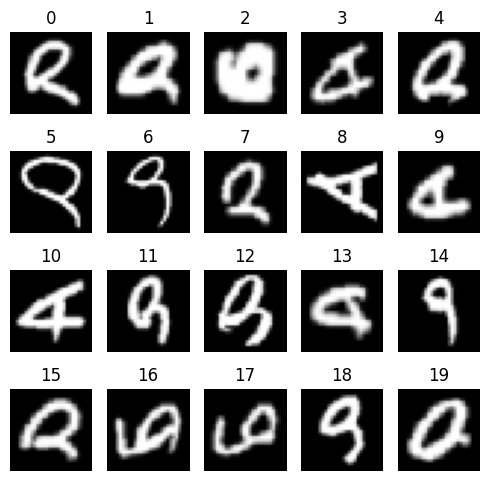

In [54]:
plt.figure(figsize=(5,5))

rows = 4
cols = 5

for i in range(rows * cols):

    img = pixels[i].reshape(28, 28)

    plt.subplot(rows, cols,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(i)
    plt.axis('off')
plt.tight_layout()
plt.show()

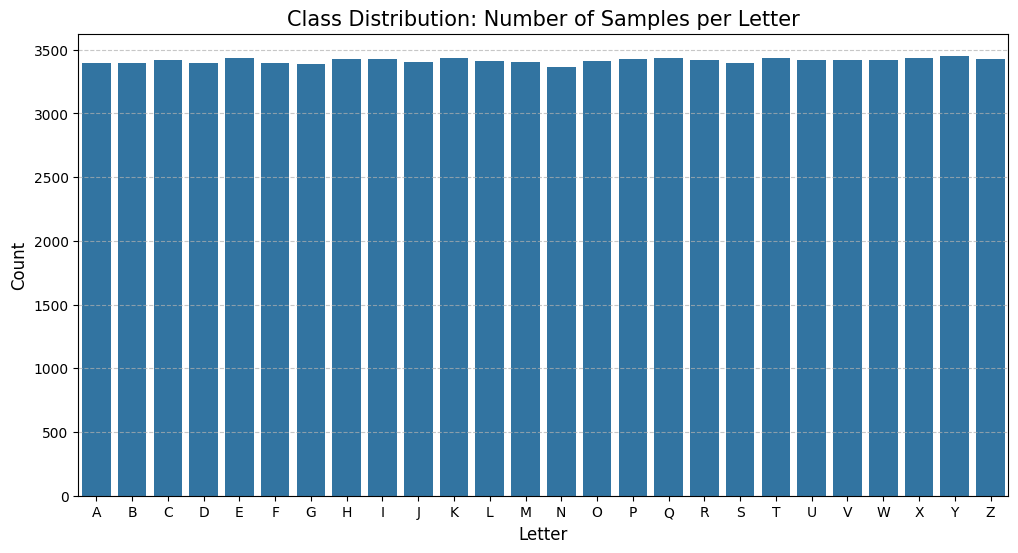

Total samples: 99039
Mean samples per class: 3415.35
Standard Deviation: 20.28


In [55]:
# Get the counts of each label
label_counts = df_clean.iloc[:, 0].value_counts().sort_index()

# Map the numeric labels (1-26) to actual letters (A-Z) for the plot
label_names = [chr(ord('A') + i - 1) for i in label_counts.index]

plt.figure(figsize=(12, 6))
sns.barplot(x=label_names, y=label_counts.values)

# Add labels and title
plt.title("Class Distribution: Number of Samples per Letter", fontsize=15)
plt.xlabel("Letter", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


print(f"Total samples: {len(df)}")
print(f"Mean samples per class: {label_counts.mean():.2f}")
print(f"Standard Deviation: {label_counts.std():.2f}")

## Data Preprocessing

Images are resized to a fixed size for consistency.
Pixel values are normalized to improve training stability.

Data augmentation is applied to:
- reduce overfitting
- improve generalization
- simulate unseen variations

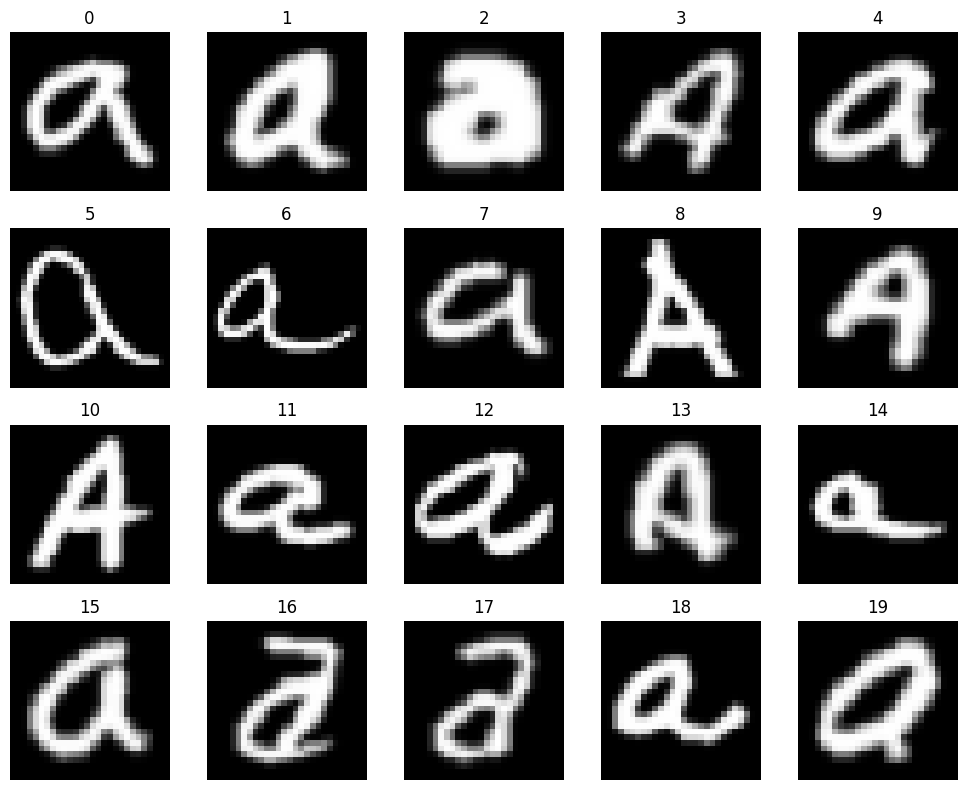

In [56]:
plt.figure(figsize=(10, 8))

rows = 4
cols = 5

for i in range(rows * cols):
    
    # the EMNIST format is column-major and i transformed it to row-major to align with standard image processing libraries
    img = pixels[i].reshape(28, 28).T

    plt.subplot(rows, cols,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(i)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [58]:
# Before augmenting, reshape the data into the 4D format that Keras expects: (batch_size, height, width, channels)
#  Assuming 'pixels' is X and 'labels' is y
# Normalize pixels to [0, 1] for better CNN convergence
X = pixels.astype('float32') / 255.0

# Reshape to (Samples, 28, 28, 1) and Transpose
X = X.reshape(-1, 28, 28)
X = np.array([img.T for img in X])
X = X.reshape(-1, 28, 28, 1)      # Add the '1' for grayscale channel

# One-hot encode labels (EMNIST letters are 1-26)
from tensorflow.keras.utils import to_categorical
y = to_categorical(labels - 1, num_classes=26)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [59]:
datagen = ImageDataGenerator(
    rotation_range=10,      # Slightly rotate letters
    zoom_range=0.1,         # Zoom in/out slightly
    width_shift_range=0.1,  # Shift left/right
    height_shift_range=0.1, # Shift up/down
    # horizontal_flip = false
)

# Fit the generator to the training data
datagen.fit(X_train)

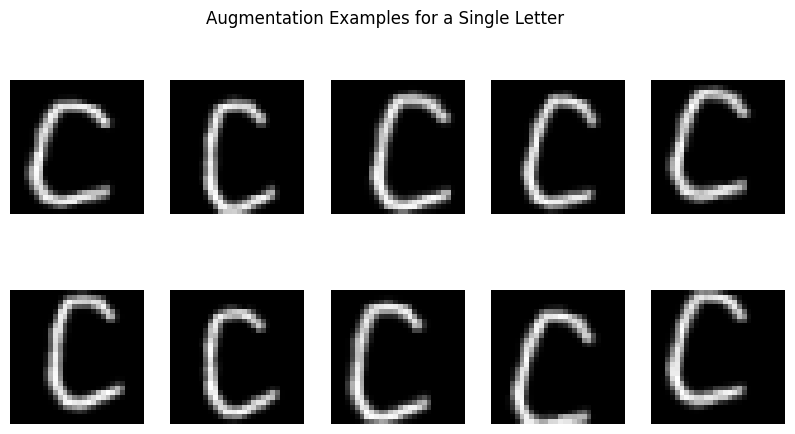

In [60]:
# Pick an image to see the variation
sample_img = X_train[0].reshape(1, 28, 28, 1)
it = datagen.flow(sample_img, batch_size=1)

plt.figure(figsize=(10, 5))
plt.suptitle("Augmentation Examples for a Single Letter")

for i in range(10):
    plt.subplot(2, 5, i + 1)
    batch = it.next()
    img = batch[0].reshape(28, 28)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
plt.show()

# Modelling and evaluation

In [ ]:
model = Sequential([
    # First Convolutional Block
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Second Convolutional Block
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Flattening and Dense Layers
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    
    # Output Layer: 26 neurons for A-Z
    Dense(26, activation='softmax') 
])

model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

model.summary()

In [ ]:
# Stop if validation loss doesn't improve for 3 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Save the best version of model to an .h5 file
checkpoint = ModelCheckpoint('best_emnist_model.h5', monitor='val_accuracy', save_best_only=True)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=20,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, checkpoint]
)

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Evolution')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Evolution')
plt.legend()
plt.show()

In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

conf_mtx = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(15, 12))
sns.heatmap(conf_mtx, annot=True, fmt='d', cmap='Blues',
            xticklabels=[chr(ord('A')+i) for i in range(26)],
            yticklabels=[chr(ord('A')+i) for i in range(26)])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

print(classification_report(y_true, y_pred_classes))